# Homework: Curve Fitting and Regularization 
$
\newcommand{\xv}{\mathbf{x}}
\newcommand{\wv}{\mathbf{w}}
\newcommand{\yv}{\mathbf{y}}
\newcommand{\tv}{\mathbf{t}}
\newcommand{\zv}{\mathbf{z}}
\newcommand{\uv}{\mathbf{u}}
\newcommand{\vv}{\mathbf{v}}
\newcommand{\bv}{\mathbf{b}}
\newcommand{\av}{\mathbf{a}}
\newcommand{\Chi}{\mathcal{X}}
\newcommand{\R}{\rm I\!R}
\newcommand{\sign}{\text{sign}}
\newcommand{\Ym}{\mathbf{Y}}
\newcommand{\Tm}{\mathbf{T}}
\newcommand{\Xm}{\mathbf{X}}
\newcommand{\Wm}{\mathbf{W}}
\newcommand{\Zm}{\mathbf{Z}}
\newcommand{\Um}{\mathbf{U}}
\newcommand{\Vm}{\mathbf{V}}
\newcommand{\Am}{\mathbf{A}}
\newcommand{\muv}{\boldsymbol\mu}
\newcommand{\Sigmav}{\boldsymbol\Sigma}
\newcommand{\Lambdav}{\boldsymbol\Lambda}
$

## Name: <span style="color:blue"> *Tyler Hudson* </span>

## Utils

In [8]:
from typing import List, Dict, Tuple, Callable
import os
import gc
import traceback
import warnings
from pdb import set_trace

import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
class TodoCheckFailed(Exception):
    pass

def todo_check(asserts, mute=False, success_msg="", **kwargs):
    locals().update(kwargs)
    failed_err = "You passed {}/{} and FAILED the following code checks:\n{}"
    failed = ""
    n_failed = 0
    for check, (condi, err) in enumerate(asserts):
        exc_failed = False
        if isinstance(condi, str):
            try:
                passed = eval(condi)
            except Exception:
                exc_failed = True
                n_failed += 1
                failed += f"\nCheck [{check+1}]: Failed to execute check [{check+1}] due to the following error...\n{traceback.format_exc()}"
        elif isinstance(condi, bool):
            passed = condi
        else:
            raise ValueError("asserts must be a list of strings or bools")

        if not exc_failed and not passed:
            n_failed += 1
            failed += f"\nCheck [{check+1}]: Failed\n\tTip: {err}\n"

    if len(failed) != 0:
        passed = len(asserts) - n_failed
        err = failed_err.format(passed, len(asserts), failed)
        raise TodoCheckFailed(err.format(failed))
    if not mute: print(f"Your code PASSED all the code checks! {success_msg}")

## Instructions
In this assignment, you will be implementing curve fitting through polynomial regression and regularization through ridge regression. This will be done for both the ordinary least squares (OLS) and least mean squares (LMS) algorithms. Additionally, you will explore norms, data splitting (now including a validation dataset), generating polynomial features, and hyperparameter selection. 

Your job is to read through the assignment and fill in any code segments that are marked by `TODO` headers and comments. Some TODOs will have a `todo_check()` function which will give you a rough estimate of whether your code is functioning as excepted. Other's might not have these checks, like visualization TODOs. Regardless,  all the correct outputs are given below each code cell. It might be useful to copy the contents of certain TODO cells into a new cell so you can try to match the desired output with the output produced by your own code! For visualization TODOs, you simply have to have a plot that looks similar. You can change aspects such as color, titles, or x/y-axis labels if you so wish.

At any point, if you feel lost concerning how to program a specific TODO, take some time and visit the official documentation for each library and read about the methods/functions that you need to use.

## Submission

1. Save the notebook.
2. Enter your name in the appropriate markdown cell provided at the top of the notebook.
3. Select `Kernel` -> `Restart Kernel and Run All Cells`. This will restart the kernel and run all cells. Make sure everything runs without errors and double-check the outputs are as you desire!
4. Submit the `.ipynb` notebook on Canvas.


# Norms

#### TODO 1 (5 points): L1 Norm


Finish the `l1_norm()` function by converting the squared $\ell_1$ norm equation into code and returning its output. The returned output should be a float.

$$
||\xv||_1 =  \sum_{m=0}^M |x_m|
$$

In [14]:
def l1_norm(x: np.ndarray) -> float:
    """ Computes the L1 norm 

        Args:
            x: A 1D or 2D column vector 

        Return:
            A float corresponding to the L1 norm
    """
    # TODO 1
    
    return np.sum(np.abs(x)) # I used chatGPT to help me with this, I initially wrote a loop, but this is more effecient

In [16]:
def TEST_l1_norm():
    print("-"*50)
    x = np.array([1, 1, 0, 1, 0, 1, 0, 1])
    print(f"x shape: {x.shape}")
    x_norm = l1_norm(x)
    print(f"L1 Norm for x: {x_norm}")
    print("-"*50)
    v = np.array([[3.45, 12.231, -9.232, 1.232, 5.32, 10.23]]).T
    print(f"v shape: {v.shape}")
    v_norm = l1_norm(v)
    print(f"L1 Norm for v: {v_norm}")
    print("-"*50)
    todo_check([
        ("x_norm == 5", "x_norm does not appear to have to correct norm value."),
        ("np.isclose(v_norm,  41.695, rtol=0.01)", "v_norm does not appear to have to correct norm value.")
    ], **locals())
TEST_l1_norm()

--------------------------------------------------
x shape: (8,)
L1 Norm for x: 5
--------------------------------------------------
v shape: (6, 1)
L1 Norm for v: 41.695
--------------------------------------------------
Your code PASSED all the code checks! 


#### TODO 2 (5 points): L2 Norm

Finish the `squared_l2_norm()` function by converting the squared $\ell_2$ norm equation into code and returning its output. The returned output should be a float.

$$
||\xv||_2^2 = \Bigr ( \sqrt{ \sum_{m=0}^M x_m^2 } \Bigr )^2 
$$

In [18]:
def squared_l2_norm(x: np.ndarray) -> float:
    """ Computes the squared L2 norm 

        Args:
            x: A 1D or 2D column vector 

        Return:
            A float corresponding to the squared L2 norm
    """
    # TODO 2
    
    return np.sum(x * x)

In [20]:
def TEST_squared_l2_norm():
    print("-"*50)
    x = np.array([1, 1, 0, 1, 0, 1])
    print(f"x shape: {x.shape}")
    x_norm = squared_l2_norm(x)
    print(f"Squared L2 Norm for x: {x_norm}")
    print("-"*50)
    v = np.array([[3.45, 12.231, -0.232, 1.232, 5.32, 10.23]]).T
    print(f"v shape: {v.shape}")
    v_norm = squared_l2_norm(v)
    print(f"Squared L2 Norm for v: {v_norm}")
    print("-"*50)
    todo_check([
        ("x_norm == 4", "x_norm does not appear to have to correct norm value."),
        ("np.isclose(v_norm,  296.0268, rtol=0.01)", "v_norm does not appear to have to correct norm value.")
    ], **locals())
TEST_squared_l2_norm()

--------------------------------------------------
x shape: (6,)
Squared L2 Norm for x: 4
--------------------------------------------------
v shape: (6, 1)
Squared L2 Norm for v: 296.026809
--------------------------------------------------
Your code PASSED all the code checks! 


# Curve Fitting and Regularization

## Concrete Compressive Strength Dataset
<center><img src="https://www.constructionplusasia.com/wp-content/uploads/2020/09/Bridge_image-by-Gubin-Yury.jpg" width=600 height=200></center>

In this assignment, we will look at a non-linear dataset called the [Concrete Compressive Strength](https://archive.ics.uci.edu/static/public/165/concrete+compressive+strength.zip) dataset. The goal of this dataset is to predict the strength of a piece of concrete given various different ingredients and age. Below, we have added the description of the dataset and its variables. The target variable is "Concrete compressive strength" or more simply referred to as "Strength."  

> Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and 
ingredients. These ingredients include cement, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, and fine aggregate.


    Variable Information:
    
    Given is the variable name, variable type, the measurement unit and a brief description. The concrete compressive strength is the regression problem. The order of this listing corresponds to the order of numerals along the rows of the database. 
    
    Name -- Data Type -- Measurement -- Description
    Cement (component 1) -- quantitative -- kg in a m3 mixture -- Input Variable
    Blast Furnace Slag (component 2) -- quantitative -- kg in a m3 mixture -- Input Variable
    Fly Ash (component 3) -- quantitative -- kg in a m3 mixture -- Input Variable
    Water (component 4) -- quantitative -- kg in a m3 mixture -- Input Variable
    Superplasticizer (component 5) -- quantitative -- kg in a m3 mixture -- Input Variable
    Coarse Aggregate (component 6) -- quantitative -- kg in a m3 mixture -- Input Variable
    Fine Aggregate (component 7) -- quantitative -- kg in a m3 mixture -- Input Variable
    Age -- quantitative -- Day (1~365) -- Input Variable
    Strength -- quantitative -- MPa -- Target Variable 

#### TODO 3 (2 points): Data Loading
Complete the TODO by loading the Concrete Compressive Strength. Do so by downloading the "Concrete_Data.csv" file from Canvas, move the file to the same directory as this notebook, and load the file using Pandas. Store the output into the `concrete_df` variable.

**WARNING: Do NOT pass a path specific to your computer! If you do, the TAs will not be able to run your notebook without making changes to it. This is why we are having you move the dataset into the same directory as this notebook.**

In [35]:
# TODO 3
concrete_df = pd.read_csv('Concrete_Data.csv')


In [26]:
todo_check([
    ("os.path.exists('Concrete_Data.csv')", f"The Concrete_Data.csv is not detected in your local path! You need to move the 'Concrete_Data.csv' file to the same location/directory as this notebook which is {os.getcwd()}"),
    ("np.all(concrete_df.iloc[0].values == np.array([ 540.  ,    0.  ,    0.  ,  162.  ,    2.5 , 1040.  ,  676.  ,28.  ,   79.99], \
      dtype=object))", 'The 1st row does not match! Make sure you loaded the right dataset!')
])

Your code PASSED all the code checks! 


In [9]:
concrete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Cement            1030 non-null   float64
 1   BlastFurnaceSlag  1030 non-null   float64
 2   FlyAsh            1030 non-null   float64
 3   Water             1030 non-null   float64
 4   Superplasticizer  1030 non-null   float64
 5   CoarseAggregate   1030 non-null   float64
 6   FineAggregate     1030 non-null   float64
 7   Age               1030 non-null   int64  
 8   Strength          1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [28]:
concrete_df.describe()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


## Visualization

#### TODO 4 (10 points): Visualization and Exploration

Create 2 visualizes of the concrete data. For each visualization, explain why you chose the visualization and then what information or insights you gained from the visualization. Feel free to reuse prior visualization you have created in the class.

1. Create your 1st visualization.
<br><br>
2. Write about your observations in 1–2 paragraphs. You MUST cover the following points to receive full credit.
    1. What was your reasoning for selecting this visualization?
    2. Discuss and explain at least 2 observations about the visualization.

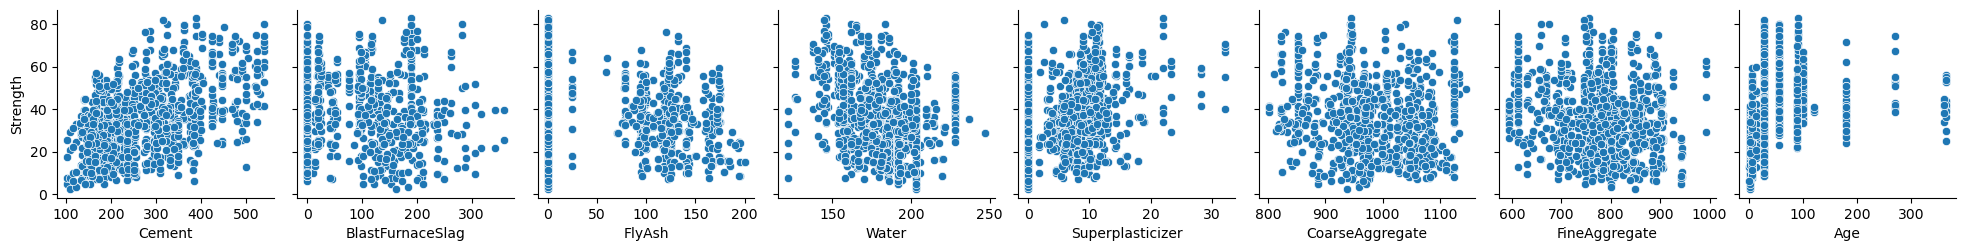

In [37]:
# TODO 4.1

import seaborn as sns

sns.pairplot(concrete_df, y_vars=["Strength"], x_vars=concrete_df.columns.drop('Strength'))
plt.show()



`TODO 4.2` Write your thoughts in the below markdown cell next to the words `Answer:` 

DO NOT WRITE YOUR ANSWER IN THIS CELL!


`Answer:`

A. I chose to compare all the features to the label because I am mostly interested in how values correlate with the strength.

B. This visual was helpful in understanding how the features correlate with strength. From the 8 graphs, I can see that cement, Superplaticizer, and age are all positvely correlated with Strength. For the most part, the other features have a very low correlation with strength. I think age has the most interesting graph, As age increases from 0 to round 200 there is a positive trend, and then as it ages further it starts to trend downwards slightly. 

## Data Preprocessing

### Polynomial Features
The first new preprocessing step will be to add the polynomial features so that polynomial curve fitting (i.e., non-linear regression) can be done. 

#### TODO 5 (10 points): Polynomial Feature Creation

Complete the `poly_features()` function by computing the polynomial features `X_poly` given the passed data `X` and degree `degree`. You can NOT use Sklearn, this must be coded from scratch using Python and NumPy. The returned output should be a matrix given as a NumPy array containing the original features and the new polynomial features in order of degree (see below example).

**Example**

The input
$
\Xm = \begin{bmatrix}
2 & 3  \\
10 & 20 \\
5 & 15  \\
\end{bmatrix}
$ should procure the following polynomial features for a degree of 3:

$$
\Xm_\text{poly} = \begin{bmatrix}
2 & 3 & 4 & 9 & 8 & 27 & \\
10 & 20 & 100 & 400 & 1000 & 8000 & \\
5 & 15  & 25 & 225 & 125 & 3375 & \\
\end{bmatrix}
$$

If the degree is 1, the original array should be returned. 

**Hints**
- Loop-over the degrees, computing the polynomial features and stacking/appending each new array as you go.

In [44]:
def poly_features(X: np.ndarray, degree: int) -> np.ndarray:
    """ Compute polynomial features for pass data

        Args:
            X: Matrix of input data for which polynomial features
                will be computed for.

            degree: The degree of the polynomial which will be computed.

        Return:
            A matrix containing the original data and the new polynomial data.
    """
   
    # TODO 5    
    X_poly = X.copy()
    
    for i in range(2, degree + 1):
        X_poly = np.hstack((X_poly, X ** i))
    
    return X_poly


In [46]:
def TEST_poly_features():
    X = np.array([
        [2, 3],
        [10, 20],
        [5, 15]
    ])
    degree = 3
    print(f"Original features:\n{X}")
    print(f"Degree: {degree}")
    X_poly = poly_features(X, degree=degree)
    print(f"Polynomial Features:\n{X_poly}")

    todo_check([
        ("isinstance(X_poly, np.ndarray)", "X_poly must be a NumPy array."),
        ('(poly_features(X, degree=1) == X).all()', 'Degree 1 did not return the original array.'),
        ('(poly_features(X, degree=3)[-1, -1] == 3375)', 'Degree 3 did not produce the expected feautre for the last row and column.'),
        ('(poly_features(X, degree=3).sum() == 13353)', 'Degree 3 did not produce the expected feautres.'),
        ('(poly_features(X, degree=5)[1, 5] == 8000)', 'Degree 5 did not produce the expected feautre for the 2nd row and 6th column.'),
        ('(poly_features(X, degree=5).sum() == 4297475)', 'Degree 5 did not produce the expected feautres.'),
    ], **locals())
    
TEST_poly_features()

Original features:
[[ 2  3]
 [10 20]
 [ 5 15]]
Degree: 3
Polynomial Features:
[[   2    3    4    9    8   27]
 [  10   20  100  400 1000 8000]
 [   5   15   25  225  125 3375]]
Your code PASSED all the code checks! 


### Data Splitting
The next new step will be to split the data into a train, validation, and test set. The validation set will be used to create learning curves later on.  

#### TODO 6 (3 points): Train, Validation, and Test Splits

Complete the `get_train_test_data()` function by following the below TODO steps. This time you will use `train_test_split()` function from Sklearn, which will randomize the data and split it for you.

**Creating Test Set**

1. Using the passed data/targets, call Sklearn's `train_test_split()` function such that the train set is 80% of the data and the test set is 20% of the data. Additionally, pass a seed of 42 for the random state. Store the output into `X_trn`, `X_tst`, `y_trn`, and `y_tst`.
<br><br>

**Creating Validation Set**

2. Using the training data/targets, call Sklearn's `train_test_split()` function again, such that the train set is 80% of the data and the validation set is 20% of the data. Additionally, pass a seed of 42 for the random state. Store the output into `X_trn`, `X_vld`, `y_trn`, and `y_vld`.
    1. Hint: This is the same as prior TODO step but now you are passing different data.

In [60]:
from sklearn.model_selection import train_test_split

def get_train_valid_test_data(
    X: np.ndarray, 
    y: np.ndarray, 
) -> Tuple[np.ndarray]:
    """ Randomizes and then splits the data into train, validation, and test sets.

        Args:
            X: Data given as a 2D matrix

            y: Labels given as a vector 
    """
    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst= None, None, None, None, None, None
    # TODO 6.1
    X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, test_size = 0.2, random_state = 42)
    
    # TODO 6.2
    X_trn, X_vld, y_trn, y_vld = train_test_split(X_trn, y_trn, test_size = 0.2, random_state = 42)

    
    return X_trn, y_trn, X_vld, y_vld, X_tst, y_tst

In [62]:
def TEST_get_train_valid_test_dataa():
    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_train_valid_test_data(
        X=concrete_df.drop('Strength', axis=1).values, 
        y=concrete_df['Strength'].values
    )
    print(f"X_trn shape: {X_trn.shape}")
    print(f"X_vld shape: {X_vld.shape}")
    print(f"X_tst shape: {X_tst.shape}")
    
    print(f"y_trn shape: {y_trn.shape}")
    print(f"y_vld shape: {y_vld.shape}")
    print(f"y_tst shape: {y_tst.shape}")
    
    todo_check([
        ("isinstance(X_trn, np.ndarray)", "X_trn must be a NumPy array."),
        ("isinstance(X_vld, np.ndarray)", "X_vld must be a NumPy array."),
        ("isinstance(X_tst, np.ndarray)", "X_tst must be a NumPy array."),
        ("isinstance(y_trn, np.ndarray)", "y_trn must be a NumPy array."),
        ("isinstance(y_vld, np.ndarray)", "y_vld must be a NumPy array."),
        ("isinstance(y_tst, np.ndarray)", "y_tst must be a NumPy array."),
        ("len(y_trn) == 659", "Training data has incorrect number of data samples."),
        ("len(y_vld) == 165", "Validation data has incorrect number of data samples."),
        ("len(y_tst) == 206", "Testing data has incorrect number of data samples."),
        ("np.isclose(X_trn[15].sum(),2360.0, rtol=0.01)", "X_trn value was not correct, check implementation and random_state."),
        ("np.isclose(X_vld[15].sum(),2326.8, rtol=0.01)", "X_vld value was not correct, check implementation and random_state."),
        ("np.isclose(X_tst[17].sum(), 2299.2, rtol=0.01)", "X_tst value was not correct, check implementation and random_state."),
        ("np.isclose(y_trn[10], 33.3, rtol=0.01)", "y_trn value was not correct, check implementation and random_state."),
        ("np.isclose(y_vld[11], 53.96, rtol=0.01)", "y_vld value was not correct, check implementation and random_state."),
        ("np.isclose(y_tst[17], 19.35, rtol=0.01)", "y_tst value was not correct, check implementation and random_state."),
    ], **locals())
TEST_get_train_valid_test_dataa()

X_trn shape: (659, 8)
X_vld shape: (165, 8)
X_tst shape: (206, 8)
y_trn shape: (659,)
y_vld shape: (165,)
y_tst shape: (206,)
Your code PASSED all the code checks! 


### Putting it all together

Recall, in order to prepare the data, you will need to split the data, standardize, and add the bias. However, now you will need to compute the polynomial features before doing any of these steps. Thus, it is time to combine all the data preprocessing steps into one function which returns the fully preprocessed data.

#### TODO 7 (5 points): Preprocess Data

Complete the following the `get_preprocessed_data()` function for performing data preprocessing.

1. Compute the polynomial features for the data by calling the `poly_features()` function. Store the output into `X_poly`.
    1. Hint: Do so by passing `X` as the data and `degree` as the degrees. 
<br><br>
2. Call the `get_train_valid_test_data()` function to split the data. Store the output into `X_trn`, `y_trn`, `X_vld`, `y_vld`, `X_tst`, and `y_tst`.
    1. Hint: Do so using `X_poly` and `y`.
<br><br>
3. Use Sklearn's `StandardScaler` class to standardize all the datasets. Do so by computing the mean and STD using the training data, and then transforming the training, validation, and testing data. Store the outputs back inside `X_trn`, `X_vld`, and `X_tst`.
<br><br>
4. Add the bias to the first column of the training `X_trn`, validation `X_vld`, and testing `X_tst` data. Store the outputs back into `X_trn`, `X_vld`, and `X_tst`.

In [68]:
from sklearn.preprocessing import StandardScaler

def get_preprocessed_data(degree: int)  -> Tuple[np.ndarray]:
    """ Gets preprocessed data for training, validation, and testing

        Args:
            degree: The degree to use when computing polynomial features. 
        
        Return:
            A tuple of NumPy arrays where indices 0-1 
            contain the training data/targets, indices 2-3
            contain the validation data/targets, and 4-5
            contain the testing data/targets.
    """
    X = concrete_df.drop('Strength', axis=1).values
    y = concrete_df['Strength'].values

    # TODO 7.1
    X_poly = poly_features(X, degree)
    
    # TODO 7.2
    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_train_valid_test_data(X_poly, y)

    # TODO 7.3
    scaler = StandardScaler() # learned about StandardScaler with some Google searches
    
    X_trn = scaler.fit_transform(X_trn)
    
    X_vld = scaler.transform(X_vld)
    X_tst = scaler.transform(X_tst)
    
    # TODO 7.4
    X_trn = np.hstack([np.ones((X_trn.shape[0], 1)), X_trn])
    X_vld = np.hstack([np.ones((X_vld.shape[0], 1)), X_vld])
    X_tst = np.hstack([np.ones((X_tst.shape[0], 1)), X_tst])

    # Reshape targets to be 2D column vectors
    return X_trn, y_trn.reshape(-1, 1), X_vld, y_vld.reshape(-1, 1), X_tst, y_tst.reshape(-1, 1)

In [70]:
def TEST_get_preprocessed_data():
    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data(degree=2)
    
    print(f"X_trn shape: {X_trn.shape}")
    print(f"y_trn shape: {y_trn.shape}")

    print(f"X_vld shape: {X_vld.shape}")
    print(f"y_vld shape: {y_vld.shape}")
    
    print(f"X_tst shape: {X_tst.shape}")
    print(f"y_tst shape: {y_tst.shape}")
    
    print(f"X_trn means:\n{X_trn.mean(axis=0)}")
    print(f"X_vld means:\n{X_vld.mean(axis=0)}")
    print(f"X_tst means:\n{X_tst.mean(axis=0)}")

    todo_check([
        # Split tests
        ("isinstance(X_trn, np.ndarray)", "X_trn must be a NumPy array."),
        ("isinstance(X_vld, np.ndarray)", "X_vld must be a NumPy array."),
        ("isinstance(X_tst, np.ndarray)", "X_tst must be a NumPy array."),
        ("isinstance(y_trn, np.ndarray)", "y_trn must be a NumPy array."),
        ("isinstance(y_vld, np.ndarray)", "y_vld must be a NumPy array."),
        ("isinstance(y_tst, np.ndarray)", "y_tst must be a NumPy array."),
        ("len(y_trn) == 659", "Training data has incorrect number of data samples."),
        ("len(y_vld) == 165", "Validation data has incorrect number of data samples."),
        ("len(y_tst) == 206", "Testing data has incorrect number of data samples."),
        ("np.isclose(y_trn[10], 33.3, rtol=0.01)", "y_trn value was not correct, check implementation and random_state."),
        ("np.isclose(y_vld[11], 53.96, rtol=0.01)", "y_vld value was not correct, check implementation and random_state."),
        ("np.isclose(y_tst[17], 19.35, rtol=0.01)", "y_tst value was not correct, check implementation and random_state."),
        # Poly Features Tests
        ("X_trn.shape[-1] == 17", "X_trn does not seem to have the right number of features, expected 17."),
        ("X_vld.shape[-1] == 17", "X_vld does not seem to have the right number of features, expected 17."),
        ("X_tst.shape[-1] == 17", "X_tst does not seem to have the right number of features, expected 17."),
        ("np.isclose(X_trn[5,[2, 10, -1]], np.array([-0.8736, -0.6568, -0.2913]), rtol=0.01).all()", "X_trn does not seem to have the right number of features, expected 17."),
        # Standardization Tests
        ('np.isclose(X_trn[:, 1:].mean(axis=0).sum(), 0, rtol=0.01)', 'X_trn has potentially incorrect mean values.'),
        ('np.isclose(X_trn[:, 1:].std(axis=0).sum(), 16, rtol=0.01)', 'X_trn has potentially incorrect std values.'),
        ('np.isclose(X_vld[:, 1:].mean(axis=0).sum(), 0.19127, rtol=0.01)', 'X_vld has potentially incorrect mean values.'),
        ('np.isclose(X_vld[:, 1:].std(axis=0).sum(), 16.87540, rtol=0.01)', 'X_vld has potentially incorrect std values.'),
        ('np.isclose(X_tst[:, 1:].mean(axis=0).sum(), 0.11504, rtol=0.01)', 'X_tst has potentially incorrect mean values.'),
        ('np.isclose(X_tst[:, 1:].std(axis=0).sum(), 16.12824, rtol=0.01)', 'X_tst has potentially incorrect std values.'),
        # Bias Tests
        ("(X_trn[:, 0] == 1).all()", "The 1st column of `X_trn` does not seem to be the bias term (i.e., full of 1s)."),
        ("(X_vld[:, 0] == 1).all()", "The 1st column of `X_vld` does not seem to be the bias term (i.e., full of 1s)."),
        ("(X_tst[:, 0] == 1).all()", "The 1st column of `X_tst` does not seem to be the bias term (i.e., full of 1s)."),
    ], **locals())
    
TEST_get_preprocessed_data()

X_trn shape: (659, 17)
y_trn shape: (659, 1)
X_vld shape: (165, 17)
y_vld shape: (165, 1)
X_tst shape: (206, 17)
y_tst shape: (206, 1)
X_trn means:
[ 1.00000000e+00  1.16734518e-15 -3.89167707e-17 -5.09624378e-17
  8.83494930e-15  3.95064187e-16 -5.11140616e-16  7.17483736e-15
  9.01319147e-18 -3.78048629e-16 -8.99213262e-17 -4.15280691e-16
 -1.54049762e-15  6.34713998e-16 -1.04148691e-15 -2.07857252e-15
  1.40462587e-17]
X_vld means:
[ 1.          0.09066629 -0.17163991 -0.03834482 -0.01178644 -0.00461011
 -0.06623919  0.1465081   0.06737635  0.10579846 -0.17967591 -0.00210041
 -0.00600365  0.06216874 -0.06807437  0.15015067  0.11708334]
X_tst means:
[ 1.         -0.08529739 -0.06121586  0.07312459 -0.05681355  0.03392579
 -0.05311408  0.1207827   0.1005734  -0.12048125 -0.08095662  0.05907649
 -0.05423109  0.03885375 -0.05820271  0.11720053  0.14181879]
Your code PASSED all the code checks! 


## Metrics

In [73]:
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_squared_error as mse

## Ridge OLS
Now, it is time to code ridge regression (regularization using the $\ell_2$ norm) for OLS. See equation given below.

$$
\wv = \big(\Xm^\top \Xm + \lambda \Im \big)^{-1} \Xm^\top \yv
$$

#### TODO 8 (15 points): RidgeOrdinaryLeastSquares
**`fit()` TODOs**

Follow the below steps to implement the `fit()` method. Feel free to reuse code from prior homework.

1. Covert the ridge regression OLS equation into code to compute the optimal weights $\wv$. Make sure the bias variable is not regularized, you should only regularize the weights for the features. Store the output into `self.w`.
    1. Hint: Use `np.eye` to create an identity matrix $I$ with the shape $(N, N)$. Set the first element value to zero to prevent the bias from being regularized as the bias is represented by the first column in the data.

**`predict()` TODOs**

Follow the below steps to implement the `predict()` method. Feel free to reuse code from prior homework.

2. Compute the predictions by taking the linear combination between the weights and passed data. Return the predictions as a 2D column vector.

In [77]:
class RidgeOrdinaryLeastSquares():
    """ Perfroms ordinary least squares regression
    
        Attributes:

            lamb (float): Regularization parameter for controlling
                L2 regularization.

            w: Vector of weights 

    """
    def __init__(self, lamb: float):
        self.lamb = lamb
        self.w = None
        
    def fit(self, X: np.ndarray, y: np.ndarray) -> object:
        """ Train OLS to learn optimal weights

            Args:
                X: Training data given as a 2D matrix

                y: Training labels given as a 1D vector

             Returns:
                The class's own object reference. 
        """
        # TODO 8.1
        N = X.shape[1]
        I = np.eye(N)
        I[0, 0] = 0
        
        self.w = np.linalg.inv(X.T @ X + self.lamb * I) @ (X.T @ y)
        
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """ Make predictions using learned weights

            Args:
                X: Testing data given as a 2D matrix

            Returns:
                A 2D column vector of predictions for each data sample in X
        """
        # TODO 8.2
        
        return X @ self.w

Dummy X shape: (100, 2)
Dummy y shape: (100, 1)
Dummy weights shape: (2, 1)
Dummy y_hat shape: (100, 1)
Dummy Train MSE: 0.2656951963650347
Dummy Final weights: [2.4540033  0.75503289]


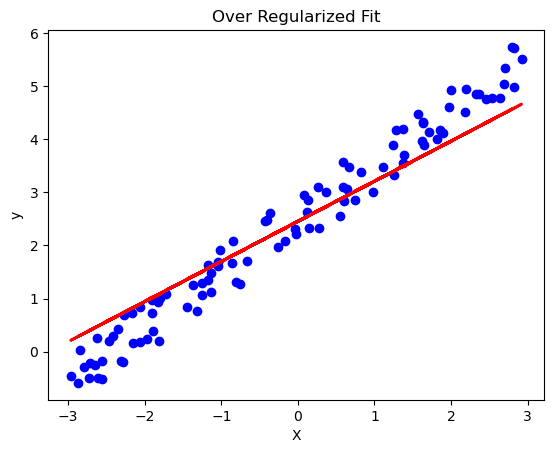

Your code PASSED all the code checks! 


In [79]:
def TEST_RidgeOrdinaryLeastSquares():    
    m = 100
    rng = np.random.RandomState(42)
    X = 6 * rng.rand(m, 1) - 3
    y = (2 + X) + rng.rand(m, 1)
    X1 = np.hstack([np.ones((len(X), 1)), X])
    print(f"Dummy X shape: {X1.shape}")
    print(f"Dummy y shape: {y.shape}")

    rols = RidgeOrdinaryLeastSquares(lamb=100)
    rols.fit(X1, y)
    print(f"Dummy weights shape: {rols.w.shape}")
    y_hat = rols.predict(X1)
    print(f"Dummy y_hat shape: {y_hat.shape}")
    trn_mse = mse(y, y_hat)
    print(f"Dummy Train MSE: {trn_mse}")
    print(f"Dummy Final weights: {rols.w.flatten()}")
    plt.title("Over Regularized Fit")
    plt.plot(X, y, 'ob')
    plt.plot(X, y_hat, '-r', linewidth=2)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.show();
    
    todo_check([
        ("mse == sklearn.metrics.mean_squared_error", "MSE does not seem to be sklearn.metrics.mean_squared_error"),
        ("np.isclose(trn_mse, 0.26569, rtol=.01)", "MSE value is potentially incorrect!"),
        ("np.all(np.isclose(rols.w.flatten(), [2.45400, 0.75503],  rtol=.1))", 'ols.w weights possibly contain incorrect values!')
    ], **locals())

TEST_RidgeOrdinaryLeastSquares()

### Concrete Training

#### TODO 9 (15 points): Ridge OLS Training and Evaluating

**WARNING: Training of the `RidgeOrdinaryLeastSquares` class should NOT take longer than 5 minutes. Excessive training times (greater than 5+ minutes) will result in reduced points or no points!**

**WARNING: The below TODO checks assume your `RidgeOrdinaryLeastSquares` object instance is called `rols`. If it has a different variable name, the below TODO checks will fail!**

Complete the code below for training the `RidgeOrdinaryLeastSquares` using the concrete dataset. To pass the TODO check(s) you will need to reduce the RMSE below multiple thresholds. For each TODO check that you pass, points will be awarded. Do so by experimenting with various hyperparameters for the following:
- Polynomial features dictated by the `degree` argument for the `get_preprocessed_data()` function.
- Regularization value for `RidgeOrdinaryLeastSquares` dictated by the `lamb` argument.


  
1. Choose a degree by setting the `degree` argument for the `get_preprocessed_data()` function.
<br><br>
2. Initialize an instance of the `RidgeOrdinaryLeastSquares` class and store the object in the variable `rols`. Train the ridge OLS algorithm and then compute the training and testing predictions, MSE, and RMSE to assess how the algorithm performed.

**Tips**
- Uncomment the code marked as `### Plotting Code ###` to plot the test targets and predictions against each other. Make sure you have the variables `y_tst` and `y_hat_tst` are defined, or replace these variables with your own.
- Uncomment the code marked as `### Display Weights ###` to display the learned weights.

Test RMSE: 6.069004986322109


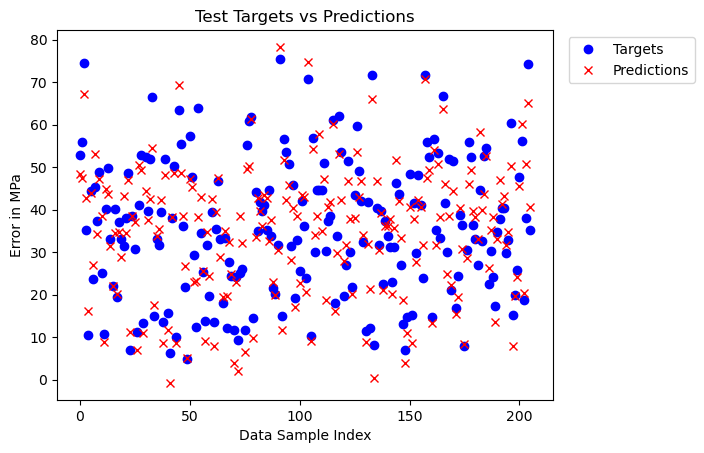

Weights:
[   36.18150228  -254.72210916   -14.35468818    71.80533466
   821.73792304    16.00349344  -359.33401863   880.50255902
    80.92129222  1043.12930461   235.26379161  -481.95911391
 -1140.694272     -78.33877716   237.72514832 -1055.51770881
  -451.61610156 -1144.44474736  -820.92182438  1020.21139446
  -676.51600702   279.27408832   291.62188424  -728.17518118
  1309.9328427   -274.35219268  1160.56663301  -461.29287851
   284.7306425   -507.35740027   125.8304125    138.78494691
 -1460.8461989    659.47094458  -246.53870892  -640.04126561
   820.81107445   103.48257044   -55.19867354   682.09857803
  -173.78340146   512.26166453  -710.5012688     70.84811914
   722.76364474   474.50117586  -150.96184653   674.25070173
   548.73903599   -79.82348957   -30.18810687   500.28424976
   193.52005258   169.16022517  -141.71875611   268.37297676
   521.64995605  -419.96637434   492.48480468   353.30889748
  -409.6967837   -294.55718948   -60.87356981  -233.44382158
   225.16230632

In [163]:
# Get training and testing data
X_trn, y_trn, _, _, X_tst, y_tst = get_preprocessed_data(
    15
)

# TODO 9.2
rols = RidgeOrdinaryLeastSquares(lamb = 0.00001)
rols.fit(X_trn, y_trn)
y_hat_trn = rols.predict(X_trn)
y_hat_tst = rols.predict(X_tst)

print(f"Test RMSE: {rmse(y_tst, rols.predict(X_tst))}")


### Plotting Code ###
plt.plot(y_tst, 'ob', label='Targets')
plt.plot(y_hat_tst, 'xr', label='Predictions')
plt.xlabel("Data Sample Index")
plt.ylabel("Error in MPa")
plt.title("Test Targets vs Predictions")
plt.legend()
plt.legend(bbox_to_anchor=(1.3, 1.00))
plt.show()

### Display Weights ###
print(f"Weights:\n{rols.w.flatten()}")

In [165]:
todo_check([
    ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
    ("rmse(y_tst, rols.predict(X_tst)) <= 6.5", "RMSE was not less than or equal to  6.5"),
],success_msg="+5 points")

Your code PASSED all the code checks! +5 points


In [167]:
todo_check([
    ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
    ("rmse(y_tst, rols.predict(X_tst)) <= 6.3", "RMSE was not less than or equal to 6.3"),
],success_msg="+5 points")

Your code PASSED all the code checks! +5 points


In [169]:
todo_check([
    ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
    ("rmse(y_tst, rols.predict(X_tst)) <= 6.1", "RMSE was not less than or equal to 6.1"),
],success_msg="+5 points")

Your code PASSED all the code checks! +5 points


## Ridge LMS
Now, it is time to code ridge regression (regularization using the $\ell_2$ norm) for LMS. See equation given below.
$$
\begin{align}
\wv_{k+1} &=  \wv_{k} - \alpha \nabla J(\wv_{k}) \\
&= \wv_{k} - \alpha \Bigr[ \lambda \wv_{k} +  \frac{1}{B}\sum_{i=0}^B \Big( {\wv_{k}}^\top \xv_i - y_i \Big) \xv_i  \Bigr ] \\
&= \wv_{k} - \alpha \Bigr[ \lambda \wv_{k} + \frac{1}{B}\sum_{i=0}^B \Big( \hat{y}_i - y_i \Big) \xv_i  \Bigr ] 
\end{align}
$$

#### TODO 10 (15 points): RidgeLeastMeanSquares
**`fit()` TODOs**

Follow the below steps to implement the `fit()` method.  Feel free to reuse code from prior homework.

1. Covert the ridge regression LMS equation into code to compute the optimal weights $\wv$. The code should loop over both epochs and batches while the weights are randomly initialized using `np.random.rand()`. Make sure the bias variable is not regularized, you should only regularize the weights assigned to the features. Store the output into `self.w`.
    1. Hint: Copy the `LeastMeanSquares` code from prior homework. 
    2. Hint: Convert `self.lamb` into a NumPy array and set the first element to 0 to prevent the bias from being regularized. It should have the same shape as `self.w`.
<br><br>
2. Add the below lines of code directly after the batch for-loop ends. It will be used to measure and store the training error for the current epoch. Learning curves will not plot without this!
```python
# Compute training/validation error for current epoch
trn_preds = self.predict(X)
trn_error = rmse(y, trn_preds)
self.trn_error.append(trn_error)

if X_vld is not None and y_vld is not None:
    vld_preds = self.predict(X_vld)
    vld_error = rmse(y_vld, vld_preds)
    self.vld_error.append(vld_error)
```

**`predict()` TODOs**

Follow the below steps to implement the `predict()` method. Feel free to reuse code from prior homework.

3. Compute the predictions by taking the linear combination between the weights and passed data. Return the predictions as a 2D column vector.

In [179]:
def get_batches(
    data_len: int, 
    batch_size: int = 32,
) -> List[np.ndarray]:
    """ Generates mini-batches based on the data indexes
        
        Args:
            data_len: Length of the data or number of data samples 
                in the data. This is used to generate the indices of
                the data.
            
            batch_size: Size of each mini-batch where the last mini-batch
                might be smaller than the rest if the batch_size does not 
                evenly divide the data length.

        Returns:
            A list of NumPy array's holding the indices of batches
    """
    indices = np.arange(data_len)
    np.random.shuffle(indices)
    batches = [indices[i:i+batch_size] for i in range(0, data_len, batch_size)]

    return batches

In [194]:
class RidgeLeastMeanSquares():
    """ Performs ridge regression using least mean squares (gradient descent)
    
        Attributes:

            alpha: learning rate or step size

            lamb (float): Regularization parameter for controlling
                L2 regularization.
                
            batch_size: Size of mini-batches for mini-batch gradient
                descent.
            
            epochs: Number of epochs to run for mini-batch
                gradient descent
                
            seed: Seed to be used for NumPy's RandomState class
                or universal seed np.random.seed() function.

            w: 1D vector of weights 

            trn_error: Stores the training error for each epoch.

            vld_error: Stores the validation error for each epoch.
    """

    def __init__(
        self, 
        alpha: float,
        lamb: float, 
        batch_size: int,
        seed: int = 0,
        epochs: int = 1,
    ):
        self.alpha = alpha
        self.lamb = lamb
        self.batch_size = batch_size
        self.epochs = epochs
        self.seed = seed
        self.w = None
        self.trn_error = None
        self.vld_error = None
    
    def fit(
         self, X: np.ndarray, 
         y: np.ndarray, 
         X_vld: np.ndarray=None, 
         y_vld: np.ndarray=None
     ) -> object:
        """ Train LMS to learn weights

            Args:
                X: Training data given as a 2D matrix

                y: Training labels given as a 2D column vector
                
            Returns:
                The class's own object reference. 
        """
        # Set seed for reproducibility
        np.random.seed(self.seed)
        # Track training/validation error
        self.trn_error = []
        self.vld_error = []
        # TODO 10.1 - 10.2

        N = X.shape[1]
        self.w = np.random.rand(N, 1)

        array_lambda = np.ones(N) * self.lamb 
        array_lambda[0] = 0

        self.trn_error = []
        self.vld_error = []

        for epoch in range(self.epochs): # Based on my old code, chatGPT helped me understand the syntax here. 
            
            batches = get_batches(data_len = X.shape[0], batch_size = self.batch_size)
            
            for batch_idx in batches:
                
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                
                preds_batch = X_batch @ self.w
                
                error = preds_batch - y_batch
                
                grad = (X_batch.T @ error) / X_batch.shape[0]
                
                self.w -= self.alpha * (grad + array_lambda[:, np.newaxis] * self.w)

            trn_prediction = self.predict(X)
            trn_error = rmse(y, trn_prediction)
            self.trn_error.append(trn_error)
        
        return self
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        """ Make predictions using learned weights

            Args:
                X: Testing data given as a 2D matrix

            Returns:
                A 2D column vector of predictions for each data sample in X
        """
        # TODO 10.3
        
        return X @ self.w

##### Online Training Test

Test `RidgeLeastMeanSquares` using batch size of 1.

Dummy X shape: (100, 2)
Dummy y shape: (100, 1)
Dummy weights shape: (2, 1)
Dummy y_hat shape: (100, 1)
Dummy Train MSE: 0.30644856144003446
Dummy Final weights: [2.42369561 0.72981414]


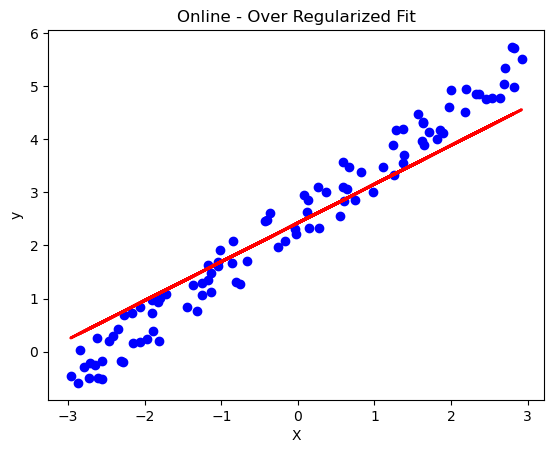

Your code PASSED all the code checks! +7.5 points


In [197]:
def TEST_online_RidgeLeastMeanSquares():    
    m = 100
    rng = np.random.RandomState(42)
    X = 6 * rng.rand(m, 1) - 3
    y = (2 + X) + rng.rand(m, 1)
    X1 = np.hstack([np.ones((len(X), 1)), X])
    print(f"Dummy X shape: {X1.shape}")
    print(f"Dummy y shape: {y.shape}")
    
    rlms = RidgeLeastMeanSquares(
        lamb=4,
        alpha=.1, 
        batch_size=1, 
        epochs=50,
        seed=42
    )
    rlms.fit(X1, y)
    print(f"Dummy weights shape: {rlms.w.shape}")
    y_hat = rlms.predict(X1)
    print(f"Dummy y_hat shape: {y_hat.shape}")
    trn_mse = mse(y, y_hat)
    print(f"Dummy Train MSE: {trn_mse}")
    print(f"Dummy Final weights: {rlms.w.flatten()}")
    plt.title("Online - Over Regularized Fit")
    plt.plot(X, y, 'ob')
    plt.plot(X, y_hat, '-r', linewidth=2)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.show();
    
    todo_check([
        ("mse == sklearn.metrics.mean_squared_error", "MSE does not seem to be sklearn.metrics.mean_squared_error"),
        ("np.isclose(trn_mse, 0.30644, rtol=.01)", "MSE value is potentially incorrect!"),
        ("np.all(np.isclose(rlms.w.flatten(), [2.4236, 0.72981],  rtol=.1))", 'rlms.w weights possibly contain incorrect values!')
    ],success_msg="+7.5 points", **locals())

TEST_online_RidgeLeastMeanSquares()

##### Minibatch Training Test

Test `RidgeLeastMeanSquares` using minibatch size 32. 

Dummy X shape: (100, 2)
Dummy y shape: (100, 1)
Dummy weights shape: (2, 1)
Dummy y_hat shape: (100, 1)
Dummy Train MSE: 0.3255091707101016
Dummy Final weights: [2.34198088 0.72485356]


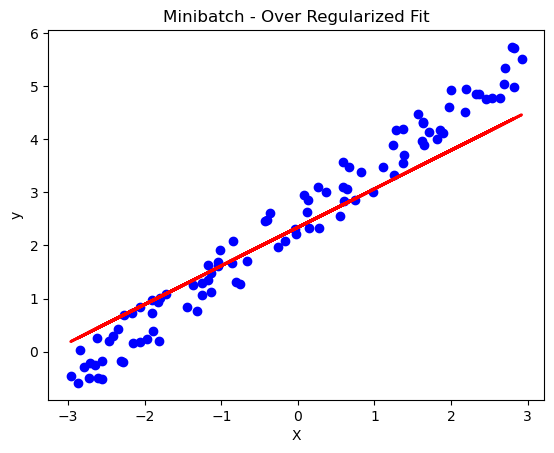

Your code PASSED all the code checks! +7.5 points


In [199]:
def TEST_minibatch_RidgeLeastMeanSquares():    
    m = 100
    rng = np.random.RandomState(42)
    X = 6 * rng.rand(m, 1) - 3
    y = (2 + X) + rng.rand(m, 1)
    X1 = np.hstack([np.ones((len(X), 1)), X])
    print(f"Dummy X shape: {X1.shape}")
    print(f"Dummy y shape: {y.shape}")
    
    rlms = RidgeLeastMeanSquares(
        lamb=2,
        alpha=.1, 
        batch_size=32, 
        epochs=50,
        seed=42
    )
    rlms.fit(X1, y)
    print(f"Dummy weights shape: {rlms.w.shape}")
    y_hat = rlms.predict(X1)
    print(f"Dummy y_hat shape: {y_hat.shape}")
    trn_mse = mse(y, y_hat)
    print(f"Dummy Train MSE: {trn_mse}")
    print(f"Dummy Final weights: {rlms.w.flatten()}")
    plt.title("Minibatch - Over Regularized Fit")
    plt.plot(X, y, 'ob')
    plt.plot(X, y_hat, '-r', linewidth=2)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.show();
    
    todo_check([
        ("mse == sklearn.metrics.mean_squared_error", "MSE does not seem to be sklearn.metrics.mean_squared_error"),
        ("np.isclose(trn_mse, 0.325509, rtol=.01)", "MSE value is potentially incorrect!"),
        ("np.all(np.isclose(rlms.w.flatten(), [2.3419, 0.72485],  rtol=.1))", 'lms.w weights possibly contain incorrect values!')
    ], success_msg="+7.5 points", **locals())

TEST_minibatch_RidgeLeastMeanSquares()

### Concrete Training

#### TODO 11 (15 points): Ridge LMS Training and Evaluating

**WARNING: Training of the `RidgeLeastMeanSquares` class should NOT take longer than 5 minutes. Excessive training times (greater than 5+ minutes) will result in reduced points or no points!**

**WARNING: The below TODO checks assume your `RidgeLeastMeanSquares` object instance is called `rlms`. If it has a different variable name, the below TODO checks will fail!**

Complete the code below for training the `RidgeLeastMeanSquares` using the concrete dataset. To pass the TODO check(s) you will need to reduce the RMSE below multiple thresholds. For each TODO check that you pass, points will be awarded. Do so by experimenting with various hyperparameters for the following:
- Polynomial features dictated by the `degree` argument for the `get_preprocessed_data()` function.
- Regularization value for `RidgeLeastMeanSquares` dictated by the `lamb` argument.
- Learning rate value for `RidgeLeastMeanSquares` dictated by the `alpha` argument.
- Epochs value for `RidgeLeastMeanSquares` dictated by the `epochs` argument.
- Batch size value for `RidgeLeastMeanSquares` dictated by the `batch_size` argument.

1. Choose a degree by setting the `degree` argument for the `get_preprocessed_data()` function.
<br><br>
2. Initialize an instance of the `RidgeLeastMeanSquares` class and store the object in the variable `rlms`. Train the ridge LMS algorithm and pass both the training and validation data. Finally, compute the training and testing predictions, MSE, and RMSE to assess how the algorithm performed.

**Tips**
- Uncomment the code marked as `### Plotting Code ###` to plot the learning curve and to plot test targets and predictions against each other. Make sure you have the variables `y_tst` and `y_hat_tst` are defined, or replace these variables with your own.
- Uncomment the code marked as `### Display Weights ###` to display the learned weights.

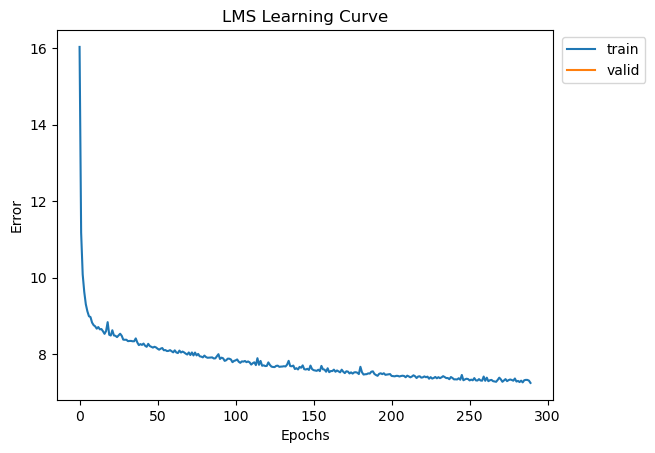

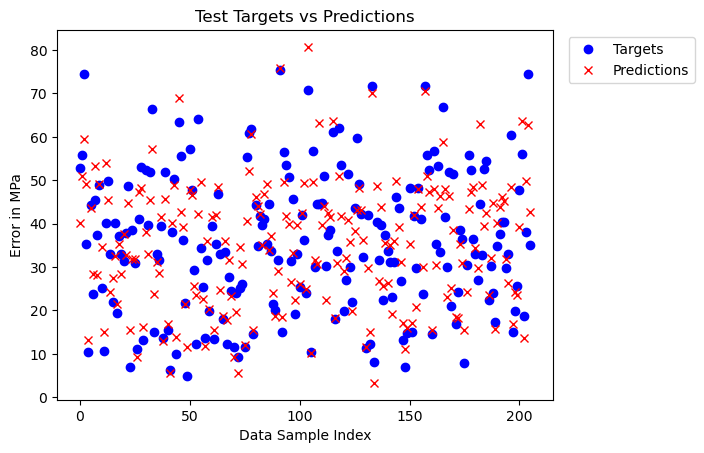

Weights:
[ 36.14263591  13.26067234   7.82224966   1.2324463   -9.45440057
  12.18833396  -2.62579529  10.34823714  27.61965093  -0.40757799
   3.23865433   1.9693131   -2.25907174 -18.90892553   0.29416253
  -0.43840089 -38.27562837  -1.05448249  -3.63436399  -1.74408624
   7.84019456   8.84368067   2.90665079  -9.30836522  17.35017609]
7.352378042736835


In [276]:
# Get training and testing data
X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data(
    3
)

# TODO 11.2
rlms = RidgeLeastMeanSquares(
    lamb = 0.00001,
    alpha = 0.05, 
    batch_size = 30, 
    epochs = 290,
    seed = 42
)

rlms.fit(X_trn, y_trn, X_vld, y_vld)

y_hat_tst = rlms.predict(X_tst)


### Plotting Code ###
#Plot learning curve
plt.plot(rlms.trn_error, label='train')
plt.plot(rlms.vld_error, label='valid')
plt.title("LMS Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend(bbox_to_anchor=(1.2, 1.00))
plt.show()

# Plot test targets and predictions
plt.plot(y_tst, 'ob', label='Targets')
plt.plot(y_hat_tst, 'xr', label='Predictions')
plt.xlabel("Data Sample Index")
plt.ylabel("Error in MPa")
plt.title("Test Targets vs Predictions")
plt.legend()
plt.legend(bbox_to_anchor=(1.3, 1.00))
plt.show()

### Display Weights ###
print(f"Weights:\n{rlms.w.flatten()}")
print(rmse(y_tst, rlms.predict(X_tst)))

In [256]:
todo_check([
    ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
    ("rmse(y_tst, rlms.predict(X_tst)) <= 8", "RMSE was not less than or equal to 8"),
],success_msg="+5 points")

Your code PASSED all the code checks! +5 points


In [258]:
todo_check([
    ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
    ("rmse(y_tst, rlms.predict(X_tst)) <= 7.5", "RMSE was not less than or equal to 7.5"),
],success_msg="+5 points")

Your code PASSED all the code checks! +5 points


In [260]:
todo_check([
    ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
    ("rmse(y_tst, rlms.predict(X_tst)) <= 7", "RMSE was not less than or equal to 7"),
],success_msg="+5 points")

TodoCheckFailed: You passed 1/2 and FAILED the following code checks:

Check [2]: Failed
	Tip: RMSE was not less than or equal to 7
